# Classic ML Pipeline for CSI Dataset

This notebook builds a full pipeline for `wifi_data_set_fixed`:
1. Read every `.data` file (each file is one data unit).
2. Build a 1D amplitude-over-time signal per unit and apply median filter with `median_width`.
3. Scale every unit using global min and max amplitude across the whole dataset.
4. Create an embedding with statistical and spectral features (including RSSI from raw data).
5. Run PCA and plot per-feature importance weighted by explained variance.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Make project root importable so `tools` can be imported from notebooks/
project_root = Path.cwd()
if not (project_root / 'tools').exists() and (project_root.parent / 'tools').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.csi_parser import Parser
from tools.filters import median_filter

# Main parameters
dataset_root = project_root / 'wifi_data_set_fixed'
median_width = 5  # must be odd

if median_width % 2 == 0:
    raise ValueError('median_width must be odd')

np.random.seed(42)

In [2]:
def parse_path_meta(file_path: Path) -> dict:
    parts = file_path.parts
    return {
        'person_id': next((p for p in parts if p.startswith('id_person_')), 'unknown'),
        'label': next((p for p in parts if p.startswith('label_')), 'unknown'),
        'test_id': next((p for p in parts if p.startswith('test_')), 'unknown'),
    }


def skewness(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean()
    sigma = x.std()
    if sigma == 0:
        return 0.0
    z = (x - mu) / sigma
    return float(np.mean(z ** 3))


def kurtosis_excess(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean()
    sigma = x.std()
    if sigma == 0:
        return 0.0
    z = (x - mu) / sigma
    return float(np.mean(z ** 4) - 3.0)


def spectral_features(signal: np.ndarray) -> tuple[float, float, float, float, float]:
    x = np.asarray(signal, dtype=np.float64)
    n = len(x)
    if n < 2:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    spectrum = np.fft.rfft(x)
    power = np.abs(spectrum) ** 2
    freqs = np.fft.rfftfreq(n, d=1.0)

    power_sum = power.sum()
    if power_sum <= 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    centroid = float((freqs * power).sum() / power_sum)
    spread = float(np.sqrt(((freqs - centroid) ** 2 * power).sum() / power_sum))

    p_norm = power / power_sum
    eps = 1e-12
    entropy = float(-(p_norm * np.log2(p_norm + eps)).sum())

    dominant_idx = int(np.argmax(power))
    dominant_freq = float(freqs[dominant_idx])
    rolloff_threshold = 0.85 * power_sum
    rolloff = float(freqs[np.searchsorted(np.cumsum(power), rolloff_threshold)])

    return centroid, spread, entropy, dominant_freq, rolloff


def build_unit_signal(df: pd.DataFrame, window: int) -> np.ndarray:
    # For each packet, reduce subcarrier amplitudes to one value by averaging.
    amp_matrix = np.stack(df['amplitude'].to_numpy(), axis=0).astype(np.float64)
    raw_time_signal = amp_matrix.mean(axis=1)
    return median_filter(raw_time_signal, window)

In [3]:
all_files = sorted(dataset_root.rglob('*.data'))
if not all_files:
    raise FileNotFoundError(f'No .data files found under {dataset_root}')

unit_cache = []
global_min = np.inf
global_max = -np.inf

for file_path in all_files:
    df = Parser(file_path).parse()
    filtered_signal = build_unit_signal(df, median_width)

    local_min = float(np.min(filtered_signal))
    local_max = float(np.max(filtered_signal))
    global_min = min(global_min, local_min)
    global_max = max(global_max, local_max)

    unit_cache.append({
        'file_path': file_path,
        'df': df,
        'filtered_signal': filtered_signal,
    })

print(f'Total units: {len(unit_cache)}')
print(f'Global amplitude min: {global_min:.6f}')
print(f'Global amplitude max: {global_max:.6f}')

Total units: 4800
Global amplitude min: 0.691347
Global amplitude max: 39.403599


In [4]:
den = global_max - global_min
if den <= 0:
    raise ValueError('Global max equals global min; cannot perform min-max scaling')

rows = []

for unit in unit_cache:
    file_path = unit['file_path']
    df = unit['df']
    signal = unit['filtered_signal']

    scaled_signal = (signal - global_min) / den
    scaled_signal = np.clip(scaled_signal, 0.0, 1.0)

    mean_val = float(np.mean(scaled_signal))
    std_val = float(np.std(scaled_signal))
    median_val = float(np.median(scaled_signal))
    min_val = float(np.min(scaled_signal))
    max_val = float(np.max(scaled_signal))
    q25 = float(np.percentile(scaled_signal, 25))
    q75 = float(np.percentile(scaled_signal, 75))
    iqr = q75 - q25
    range_val = max_val - min_val
    rms = float(np.sqrt(np.mean(scaled_signal ** 2)))
    energy = float(np.sum(scaled_signal ** 2))
    zcr = float(np.mean(np.abs(np.diff(np.signbit(scaled_signal - mean_val)).astype(np.int8))))

    sk = skewness(scaled_signal)
    kt = kurtosis_excess(scaled_signal)
    sc, ss, se, dom_freq, rolloff = spectral_features(scaled_signal)

    rssi_dbm = float(df['rssi_dbm'].median())

    meta = parse_path_meta(file_path)
    rows.append({
        'file_path': str(file_path),
        **meta,
        'n_packets': int(len(df)),
        'mean': mean_val,
        'std': std_val,
        'median': median_val,
        'skew': sk,
        'kurtosis': kt,
        'spectral_centroid': sc,
        'spectral_spread': ss,
        'spectral_entropy': se,
        'dominant_freq': dom_freq,
        'spectral_rolloff_85': rolloff,
        'min': min_val,
        'max': max_val,
        'q25': q25,
        'q75': q75,
        'iqr': iqr,
        'range': range_val,
        'rms': rms,
        'energy': energy,
        'zcr': zcr,
        'rssi_dbm': rssi_dbm,
    })

features_df = pd.DataFrame(rows)
print(features_df.shape)
features_df.head()

(4800, 25)


,file_path,person_id,label,test_id,n_packets,mean,std,median,skew,kurtosis,...,min,max,q25,q75,iqr,range,rms,energy,zcr,rssi_dbm
0,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01,100,0.478846,0.034289,0.487212,-0.721638,-0.141173,...,0.393419,0.534750,0.458449,0.501095,0.042646,0.141330,0.480072,23.046940,0.101010,-44.0
1,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01,100,0.477401,0.043657,0.483232,-1.143821,2.515272,...,0.327005,0.563487,0.458711,0.503310,0.044600,0.236482,0.479393,22.981722,0.121212,-43.0
2,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01,100,0.030793,0.012979,0.031673,0.018646,-1.304995,...,0.010490,0.052684,0.017564,0.042101,0.024537,0.042194,0.033417,0.111666,0.111111,-62.0
3,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_02,100,0.435882,0.066820,0.448617,-0.188117,-1.249239,...,0.321174,0.556928,0.358048,0.488871,0.130824,0.235754,0.440974,19.445829,0.060606,-45.0
4,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_02,100,0.433106,0.046064,0.446143,-0.660204,0.082555,...,0.329883,0.527063,0.411207,0.458553,0.047346,0.197180,0.435548,18.970242,0.101010,-44.0


In [5]:
feature_cols = [
    'mean', 'std', 'median', 'skew', 'kurtosis',
    'spectral_centroid', 'spectral_spread', 'spectral_entropy',
    'dominant_freq', 'spectral_rolloff_85',
    'min', 'max', 'q25', 'q75', 'iqr', 'range',
    'rms', 'energy', 'zcr', 'rssi_dbm'
]

X = features_df[feature_cols].to_numpy(dtype=np.float64)

# Save feature-wise min/max from train for stable inference preprocessing
feature_min = X.min(axis=0)
feature_max = X.max(axis=0)

scaler_pca = StandardScaler()
X_std = scaler_pca.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Как в вашем ноутбуке: явный расчет доли объясненной дисперсии по каждой компоненте.
evr_df = pd.DataFrame({
    'PC': np.arange(1, len(evr) + 1),
    'EVR': evr,
    'CUM_EVR': cum_evr,
})

display(evr_df.head(10))

# Берем только информативные компоненты (до 95% накопленной дисперсии),
# чтобы importance признаков не вырождалась в одинаковые 1/p.
k_95 = int(np.searchsorted(cum_evr, 0.95) + 1)
print(f'Components for 95% variance: {k_95}')

# importance_j = sum_{k=1..K}((loading_{k,j}^2) * EVR_k), K = k_95
loadings = pca.components_[:k_95, :]
feature_importance = (loadings ** 2).T @ evr[:k_95]
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print('Top 10 features by PCA-weighted importance (using first K components):')
display(importance_df.head(10))

,PC,EVR,CUM_EVR
0,1,0.607849,0.607849
1,2,0.133693,0.741542
2,3,0.064416,0.805958
3,4,0.059346,0.865304
4,5,0.050044,0.915349
5,6,0.036767,0.952116
6,7,0.023182,0.975298
7,8,0.008146,0.983444
8,9,0.006823,0.990266
9,10,0.006550,0.996817


Components for 95% variance: 6
Top 10 features by PCA-weighted importance (using first K components):


,feature,importance
13,q75,0.052361
16,rms,0.052228
11,max,0.052173
0,mean,0.052172
9,spectral_rolloff_85,0.052060
2,median,0.052000
4,kurtosis,0.051956
12,q25,0.051457
18,zcr,0.050947
3,skew,0.050758


In [9]:
print(evr)

[6.07849017e-01 1.33692619e-01 6.44161107e-02 5.93464277e-02
 5.00444690e-02 3.67672120e-02 2.31816543e-02 8.14636180e-03
 6.82261079e-03 6.55026342e-03 1.02017164e-03 9.75498958e-04
 6.52135530e-04 3.96270774e-04 1.15488161e-04 2.34215568e-05
 2.67392544e-07 2.34918552e-17 1.40057759e-18 0.00000000e+00]


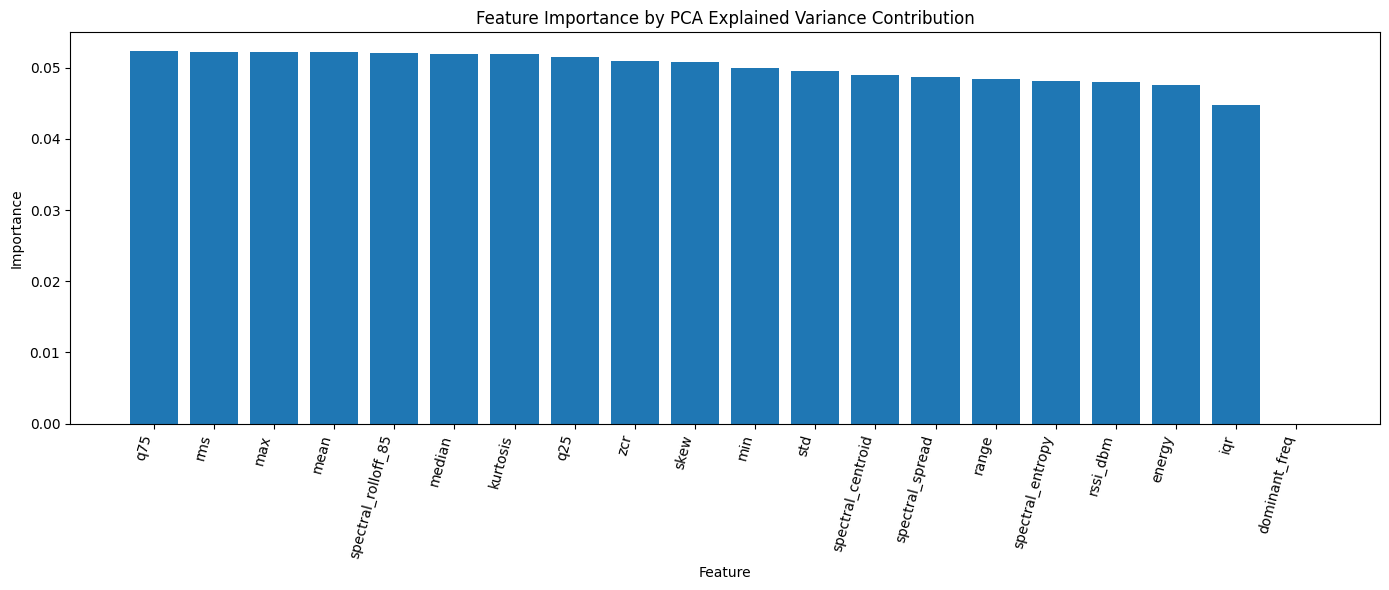

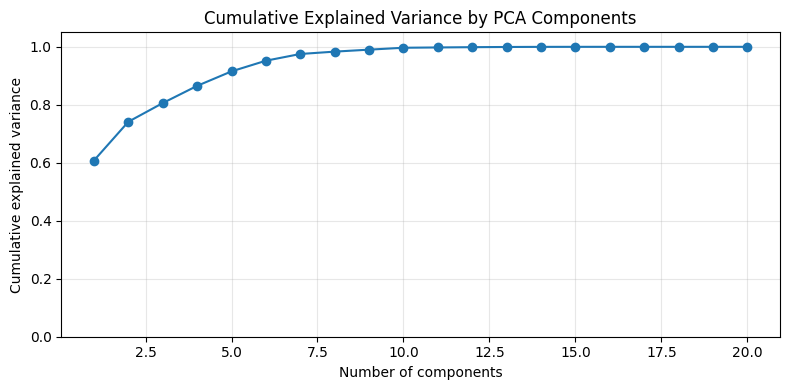

In [8]:
plt.figure(figsize=(14, 6))
plt.bar(importance_df['feature'], importance_df['importance'])
plt.title('Feature Importance by PCA Explained Variance Contribution')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
cum_evr = np.cumsum(evr)
plt.plot(np.arange(1, len(cum_evr) + 1), cum_evr, marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Binary Classification on PCA (95% EVR)
Build binary labels from folder labels:
- class `0`: samples from `label_00`
- class `1`: all other labels

Train and tune models on PCA embeddings limited to components explaining 95% variance.

In [6]:
import sys
import subprocess

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Ensure CatBoost is available in the current notebook kernel
try:
    from catboost import CatBoostClassifier
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '-q'])
    from catboost import CatBoostClassifier

# Binary target rule from dataset folders: label_00 -> 0, others -> 1
y_binary = (features_df['label'] != 'label_00').astype(int).to_numpy()

# Keep PCA embeddings only up to 95% explained variance
X_pca_95 = X_pca[:, :k_95]
print(f'X_pca_95 shape: {X_pca_95.shape}, y shape: {y_binary.shape}')
print(f'Class distribution: 0 -> {(y_binary == 0).sum()}, 1 -> {(y_binary == 1).sum()}')

X_train, X_test, y_train, y_test = train_test_split(
    X_pca_95, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_spaces = {
    'CatBoost': (
        CatBoostClassifier(
            random_seed=42,
            loss_function='Logloss',
            verbose=False
        ),
        {
            'depth': [4, 6, 8],
            'learning_rate': [0.03, 0.1],
            'iterations': [200, 400],
            'l2_leaf_reg': [3, 5]
        }
    ),
    'LogReg': (
        LogisticRegression(max_iter=5000),
        {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs'],
            'penalty': ['l2']
        }
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            'n_estimators': [300, 600],
            'max_depth': [None, 12, 24],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    ),
    'SVM': (
        SVC(probability=True, random_state=42),
        {
            'C': [0.5, 1.0, 5.0],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    ),
}

search_results = []
best_search = None

for model_name, (estimator, param_grid) in model_spaces.items():
    print(f'\nGrid search for: {model_name}')
    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test)[:, 1]
    else:
        # Fallback for models without predict_proba
        y_score = best_model.decision_function(X_test)
        y_proba = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-12)

    result = {
        'model': model_name,
        'best_cv_f1': search.best_score_,
        'test_f1': f1_score(y_test, y_pred),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_proba),
        'best_params': search.best_params_
    }
    search_results.append(result)

    if best_search is None or search.best_score_ > best_search.best_score_:
        best_search = search

results_df = pd.DataFrame(search_results).sort_values('best_cv_f1', ascending=False).reset_index(drop=True)
print('\nModel ranking by best CV F1:')
display(results_df[['model', 'best_cv_f1', 'test_f1', 'test_accuracy', 'test_roc_auc']])

best_model_name = results_df.loc[0, 'model']
best_model = best_search.best_estimator_
print(f'\nBest model: {best_model_name}')
print(f'Best CV F1: {best_search.best_score_:.4f}')
print(f'Best params: {best_search.best_params_}')

best_pred = best_model.predict(X_test)
print('\nClassification report (best model on test set):')
print(classification_report(y_test, best_pred, digits=4))

X_pca_95 shape: (4800, 6), y shape: (4800,)
Class distribution: 0 -> 1200, 1 -> 3600

Grid search for: CatBoost

Grid search for: LogReg

Grid search for: RandomForest


/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'pe


Grid search for: SVM

Model ranking by best CV F1:


,model,best_cv_f1,test_f1,test_accuracy,test_roc_auc
0,CatBoost,0.969674,0.971821,0.957292,0.985622
1,SVM,0.969131,0.974465,0.961458,0.988270
2,RandomForest,0.967460,0.972527,0.958333,0.983131
3,LogReg,0.908325,0.923182,0.883333,0.930955



Best model: CatBoost
Best CV F1: 0.9697
Best params: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1}

Classification report (best model on test set):
              precision    recall  f1-score   support

           0     0.9422    0.8833    0.9118       240
           1     0.9619    0.9819    0.9718       720

    accuracy                         0.9573       960
   macro avg     0.9521    0.9326    0.9418       960
weighted avg     0.9570    0.9573    0.9568       960



In [7]:
from pathlib import Path
import json
import joblib

if best_model_name != 'CatBoost':
    raise ValueError(f'Expected CatBoost to be the best model, got: {best_model_name}')

artifacts_dir = project_root / 'artifacts' / 'classic_ml'
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / 'catboost_model.cbm'
preproc_path = artifacts_dir / 'preprocessing.joblib'
meta_path = artifacts_dir / 'metadata.json'

# Save CatBoost model weights
best_model.save_model(str(model_path))

# Save preprocessing artifacts required for inference
preproc_bundle = {
    'median_width': median_width,
    'global_min': float(global_min),
    'global_max': float(global_max),
    'feature_cols': feature_cols,
    'feature_min': feature_min,
    'feature_max': feature_max,
    'scaler_pca': scaler_pca,
    'pca': pca,
    'k_95': int(k_95),
}
joblib.dump(preproc_bundle, preproc_path)

meta = {
    'best_model_name': best_model_name,
    'best_cv_f1': float(best_search.best_score_),
    'best_params': best_search.best_params_,
    'model_path': str(model_path),
    'preprocessing_path': str(preproc_path),
    'class_mapping': {
        '0': 'label_00',
        '1': 'label_01 | label_02 | label_03',
    },
    'preprocessing_notes': {
        'feature_clip': 'Inference clips each feature to [feature_min, feature_max] from train before StandardScaler+PCA',
    },
}
meta_path.write_text(json.dumps(meta, indent=2), encoding='utf-8')

print(f'Saved model: {model_path}')
print(f'Saved preprocessing: {preproc_path}')
print(f'Saved metadata: {meta_path}')

Saved model: /home/gleb/learning/CSI-activity-detection/artifacts/classic_ml/catboost_model.cbm
Saved preprocessing: /home/gleb/learning/CSI-activity-detection/artifacts/classic_ml/preprocessing.joblib
Saved metadata: /home/gleb/learning/CSI-activity-detection/artifacts/classic_ml/metadata.json
